In [1]:
import random, sys, time, json
import matplotlib.pyplot as plt
sys.setrecursionlimit(10000)

Matplotlib is building the font cache; this may take a moment.


Insertion Sort Implementation

In [2]:
def insertion_sort(arr, low, high, counter=None):
    for i in range(low + 1, high):
        j = i - 1
        while j >= low:
            if counter is not None:
                counter[0] += 1
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                j -= 1
            else:
                break

Merge subfunction and Merge Sort Implementation

In [3]:
def merge(arr, low, mid, high, counter=None):
    left = arr[low:mid]
    right = arr[mid:high]
    i = 0
    k = low
    for j in range(len(right)):
        while i < len(left):
            if counter is not None:
                counter[0] += 1
            if left[i] <= right[j]:
                arr[k] = left[i]
                i += 1
                k += 1
            else:
                break
        arr[k] = right[j]
        k += 1
    while i < len(left):
        arr[k] = left[i]
        i += 1
        k += 1

In [4]:
def merge_sort(arr, low, high, counter=None):
    if high - low <= 1:
        return
    mid = (low + high) // 2
    merge_sort(arr, low, mid, counter)
    merge_sort(arr, mid, high, counter)
    merge(arr, low, mid, high, counter)

Hybrid Sort Implementation (If size of array is lesser than S, swap from mergesort to insertionsort)

In [5]:
def hybrid_sort(arr, low, high, S, counter=None):
    n = high - low
    if n <= 1:
        return
    if n <= S:
        insertion_sort(arr, low, high, counter)
        return
    mid = (low + high) // 2
    hybrid_sort(arr, low, mid, S, counter)
    hybrid_sort(arr, mid, high, S, counter)
    merge(arr, low, mid, high, counter)

Dataset generation

In [6]:
MAX_VALUE = 10000000
 
def generate_data(n, max_value=MAX_VALUE, seed=None):
    rng = random.Random(seed)
    return [rng.randint(1, max_value) for _ in range(n)]

Comparison counting function

In [8]:
def count_comparisons(n, S, seed=0):
    data = generate_data(n, seed=seed)
    counter = [0]
    hybrid_sort(data, 0, len(data), S, counter)
    return counter[0]

Time measurement function

In [9]:
def time_hybrid(n, S, seed=0, trials=3):
    base = generate_data(n, seed=seed)
    times = []
    for _ in range(trials):
        arr = base.copy()
        t0 = time.process_time()
        hybrid_sort(arr, 0, len(arr), S)
        t1 = time.process_time()
        times.append(t1 - t0)
    return sum(times) / len(times)

(c)(i): fixed S, vary n -- comparisons vs n

In [10]:
def part_i():
    S_FIXED = 15
    sizes = [1_000, 2_000, 5_000, 10_000, 20_000, 50_000, 100_000,
              200_000, 500_000, 1_000_000, 2_000_000, 5_000_000, 10_000_000]
 
    results = []
    for n in sizes:
        cmp = count_comparisons(n, S_FIXED, seed=1)
        results.append((n, cmp))
        print(f"[i] n={n:>10}  comparisons={cmp:>12}")
 
    ns = [r[0] for r in results]
    cmps = [r[1] for r in results]
 
    # theoretical reference curve: hybrid comparisons ~ c * n * log(n / S) ie. O(cnlog(n/S)) that becomes O(nlogn) for fixed S, where c is a constant determined by the last data point
    import math
    n_ref, cmp_ref = ns[-1], cmps[-1]
    c = cmp_ref / (n_ref * math.log2(n_ref / S_FIXED))
    theory = [c * n * math.log2(n / S_FIXED) for n in ns]
 
    plt.figure()
    plt.plot(ns, cmps, 'o-', label='empirical (comparisons)')
    plt.plot(ns, theory, '--', label=f'theory: c*n*log2(n/S), c={c:.3f}')
    plt.xscale('log'); plt.yscale('log')
    plt.xlabel('n (input size)'); plt.ylabel('key comparisons')
    plt.title(f'(c)(i) Comparisons vs n, fixed S={S_FIXED}')
    plt.legend(); plt.grid(True, which='both', alpha=0.3)
    plt.savefig('part_c_i.png', dpi=150, bbox_inches='tight')
    print("saved part_c_i.png")
 
    with open('part_c_i.json', 'w') as f:
        json.dump({"S_fixed": S_FIXED, "data": results}, f)

(c)(ii): fixed n, vary S -- comparisons vs S

In [14]:
def part_ii():
    N_FIXED = 1_000_000
    S_values = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
 
    results = []
    for S in S_values:
        cmp = count_comparisons(N_FIXED, S, seed=1)
        results.append((S, cmp))
        print(f"[ii] S={S:>5}  comparisons={cmp:>12}")
 
    Ss = [r[0] for r in results]
    cmps = [r[1] for r in results]
 
    # Theoretical model: comparisons(S) = a * n*log2(n/S) [merge levels] + b * n*S [insertion, ~S^2/S blocks]

    import math
    import numpy as np
 
    n = N_FIXED
    f1 = np.array([n * math.log2(n / S) for S in Ss])   
    f2 = np.array([n * S for S in Ss])                   
    A = np.column_stack([f1, f2])
    y = np.array(cmps, dtype=float)
    (a, b), *_ = np.linalg.lstsq(A, y, rcond=None)
    theory = a * f1 + b * f2
 
    print(f"fitted a={a:.4f} (merge term), b={b:.4f} (insertion term)")
 
    plt.figure()
    plt.plot(Ss, cmps, 'o-', label='empirical (comparisons)')
    plt.plot(Ss, theory, '--', label=f'theory: a*n*log2(n/S) + b*n*S (a={a:.3f}, b={b:.3f})')
    plt.xscale('log')
    plt.xlabel('S (insertion-sort threshold)'); plt.ylabel('key comparisons')
    plt.title(f'(c)(ii) Comparisons vs S, fixed n={N_FIXED}')
    plt.legend(); plt.grid(True, which='both', alpha=0.3)
    plt.savefig('part_c_ii.png', dpi=150, bbox_inches='tight')
    print("saved part_c_ii.png")
 
    with open('part_c_ii.json', 'w') as f:
        json.dump({"n_fixed": N_FIXED, "data": results, "fit": {"a": a, "b": b}}, f)

 (c)(iii): "optimal" S -- by comparisons and CPU time

In [12]:
def part_iii():
    sizes = [10_000, 100_000, 1_000_000]
    S_grid_cmp = [2, 4, 8, 12, 16, 20, 24, 32, 40, 50, 64, 80, 100, 128, 160, 200, 256]
 
    by_comparisons = {}
    for n in sizes:
        row = [(S, count_comparisons(n, S, seed=1)) for S in S_grid_cmp]
        best_S, best_cmp = min(row, key=lambda t: t[1])
        by_comparisons[n] = {"sweep": row, "best_S": best_S, "best_cmp": best_cmp}
        print(f"[iii/comparisons] n={n:>9}  best S={best_S}  "
              f"(monotonic trend expected -- this will likely just be the smallest S tested)")
 
    S_grid_time = [1, 2, 4, 8, 16, 24, 32, 48, 64, 96, 128, 192, 256]
    by_time = {}
    for n in sizes:
        row = [(S, time_hybrid(n, S, seed=42, trials=3)) for S in S_grid_time]
        best_S, best_t = min(row, key=lambda t: t[1])
        by_time[n] = {"sweep": row, "best_S": best_S, "best_time": best_t}
        print(f"[iii/time] n={n:>9}  best S={best_S}  ({best_t:.4f}s)")
 
    # plot: one subplot per size, comparisons-based and time-based side by side
    fig, axes = plt.subplots(len(sizes), 2, figsize=(11, 3.2 * len(sizes)))
    for row_idx, n in enumerate(sizes):
        ax_c = axes[row_idx][0]
        Ss, cmps = zip(*by_comparisons[n]["sweep"])
        ax_c.plot(Ss, cmps, 'o-')
        ax_c.set_title(f'n={n}: comparisons vs S')
        ax_c.set_xlabel('S'); ax_c.set_ylabel('comparisons')
        ax_c.grid(alpha=0.3)
 
        ax_t = axes[row_idx][1]
        Ss2, ts = zip(*by_time[n]["sweep"])
        ax_t.plot(Ss2, ts, 'o-', color='darkorange')
        ax_t.axvline(by_time[n]["best_S"], linestyle='--', color='gray',
                     label=f'best S={by_time[n]["best_S"]}')
        ax_t.set_title(f'n={n}: CPU time vs S')
        ax_t.set_xlabel('S'); ax_t.set_ylabel('seconds')
        ax_t.legend(); ax_t.grid(alpha=0.3)
 
    plt.tight_layout()
    plt.savefig('part_c_iii.png', dpi=150, bbox_inches='tight')
    print("saved part_c_iii.png")
 
    with open('part_c_iii.json', 'w') as f:
        json.dump({"by_comparisons": by_comparisons, "by_time": by_time}, f)

=== Part (c)(i) ===
[i] n=      1000  comparisons=        9617
[i] n=      2000  comparisons=       21108
[i] n=      5000  comparisons=       58447
[i] n=     10000  comparisons=      127013
[i] n=     20000  comparisons=      274091
[i] n=     50000  comparisons=      769093
[i] n=    100000  comparisons=     1638897
[i] n=    200000  comparisons=     3477585
[i] n=    500000  comparisons=     9443243
[i] n=   1000000  comparisons=    19886004
[i] n=   2000000  comparisons=    41775676
[i] n=   5000000  comparisons=   108214220
[i] n=  10000000  comparisons=   226422219
saved part_c_i.png


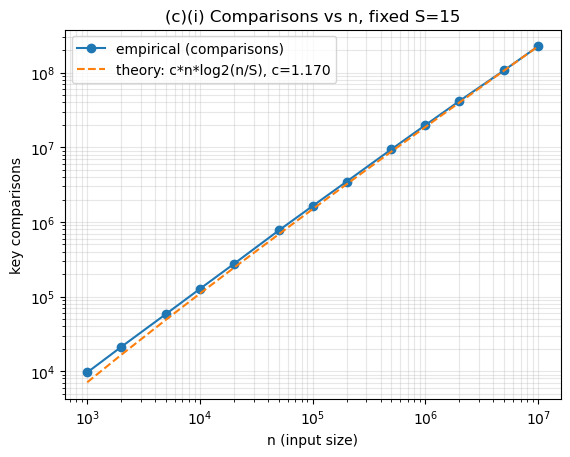

In [15]:
print("=== Part (c)(i) ===")
part_i()
    


=== Part (c)(ii) ===
[ii] S=    1  comparisons=    18674124
[ii] S=    2  comparisons=    18674124
[ii] S=    4  comparisons=    18726880
[ii] S=    8  comparisons=    19071670
[ii] S=   16  comparisons=    20220816
[ii] S=   32  comparisons=    23185861
[ii] S=   64  comparisons=    29906601
[ii] S=  128  comparisons=    44213729
[ii] S=  256  comparisons=    73789282
[ii] S=  512  comparisons=   133855650
fitted a=0.9925 (merge term), b=0.2410 (insertion term)
saved part_c_ii.png


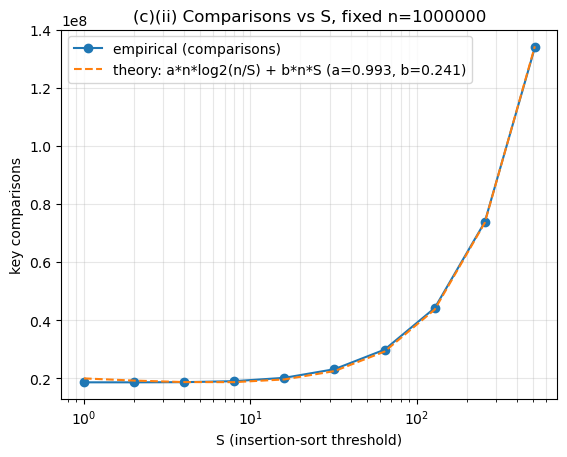

In [16]:
print("\n=== Part (c)(ii) ===")
part_ii()



=== Part (c)(iii) ===
[iii/comparisons] n=    10000  best S=2  (monotonic trend expected -- this will likely just be the smallest S tested)
[iii/comparisons] n=   100000  best S=2  (monotonic trend expected -- this will likely just be the smallest S tested)
[iii/comparisons] n=  1000000  best S=2  (monotonic trend expected -- this will likely just be the smallest S tested)
[iii/time] n=    10000  best S=16  (0.0190s)
[iii/time] n=   100000  best S=8  (0.2396s)
[iii/time] n=  1000000  best S=8  (3.0569s)
saved part_c_iii.png


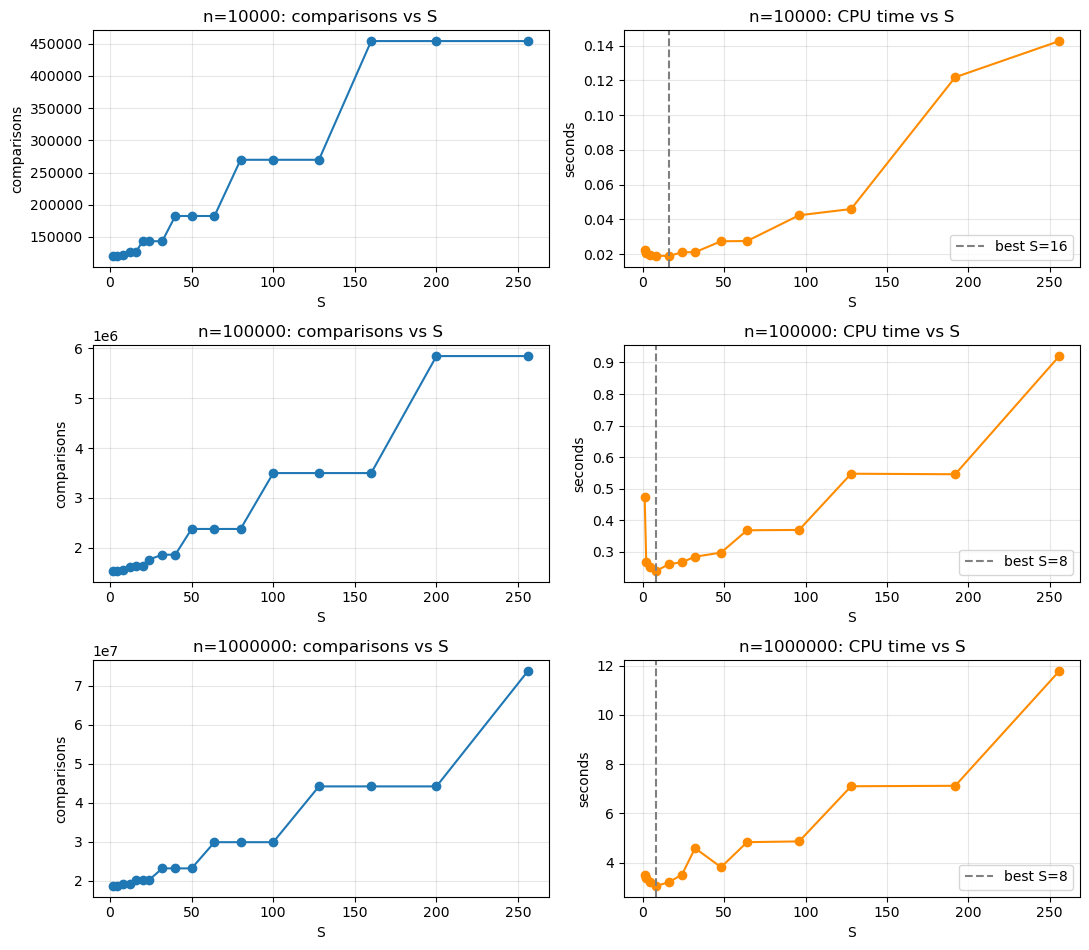

In [17]:
print("\n=== Part (c)(iii) ===")
part_iii()

(d) Comparison against original merge sort going with S=8 for optimal value

Generated dataset: n=10000000, S_OPT=8

Counting key comparisons...
  original merge sort : 220,096,034 comparisons
  hybrid (S=8)        : 221,105,906 comparisons
  difference           : -1,009,872 (-0.46% fewer for hybrid)

Timing original merge sort (3 trials)...
    trial 1/3: 47.853s
    trial 2/3: 45.555s
    trial 3/3: 46.187s

Timing hybrid sort, S=8 (3 trials)...
    trial 1/3: 44.428s
    trial 2/3: 42.260s
    trial 3/3: 42.538s

  original merge sort avg CPU time : 46.532s  [47.8534830000001, 45.55510699999991, 46.18710900000019]
  hybrid (S=8) avg CPU time: 43.075s  [44.428044, 42.25989500000014, 42.53789800000004]
  speedup: 1.080x

saved part_d_results.json
saved part_d.png


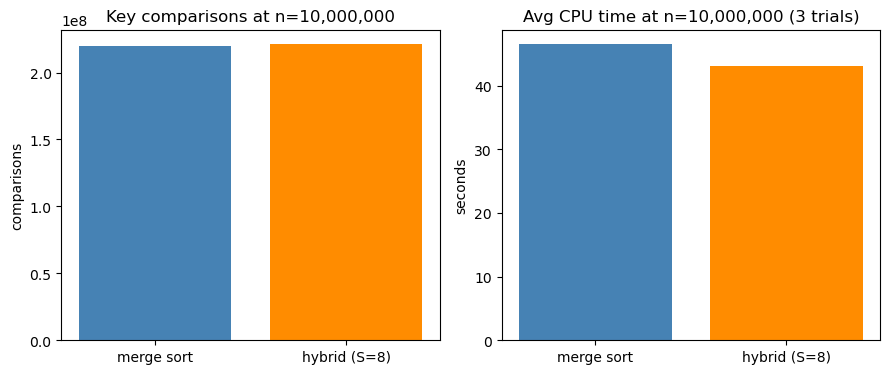

In [18]:
N = 10_000_000
TRIALS = 3
S_OPT = 8
 
data = generate_data(N, seed=123)
print(f"Generated dataset: n={N}, S_OPT={S_OPT}")
 
 
# ---------- key comparisons ----------
 
def count_merge():
    arr = data.copy()
    counter = [0]
    merge_sort(arr, 0, len(arr), counter)
    return arr, counter[0]
 
def count_hybrid(S):
    arr = data.copy()
    counter = [0]
    hybrid_sort(arr, 0, len(arr), S, counter)
    return arr, counter[0]
 
print("\nCounting key comparisons...")
arr_merge, cmp_merge = count_merge()
arr_hybrid, cmp_hybrid = count_hybrid(S_OPT)
 
assert arr_merge == arr_hybrid, "hybrid and merge sort produced different results!"
print(f"  original merge sort : {cmp_merge:,} comparisons")
print(f"  hybrid (S={S_OPT})        : {cmp_hybrid:,} comparisons")
print(f"  difference           : {cmp_merge - cmp_hybrid:,} "
      f"({(1 - cmp_hybrid/cmp_merge)*100:.2f}% fewer for hybrid)")
 
 
# ---------- CPU time (clean, uninstrumented; averaged over TRIALS) ----------
 
def time_it(fn, *args, trials=TRIALS):
    times = []
    for t in range(trials):
        arr = data.copy()
        t0 = time.process_time()
        fn(arr, 0, len(arr), *args)
        t1 = time.process_time()
        times.append(t1 - t0)
        print(f"    trial {t+1}/{trials}: {t1-t0:.3f}s")
    return times
 
print(f"\nTiming original merge sort ({TRIALS} trials)...")
merge_times = time_it(merge_sort)
 
print(f"\nTiming hybrid sort, S={S_OPT} ({TRIALS} trials)...")
hybrid_times = time_it(hybrid_sort, S_OPT)
 
merge_avg = sum(merge_times) / len(merge_times)
hybrid_avg = sum(hybrid_times) / len(hybrid_times)
 
print(f"\n  original merge sort avg CPU time : {merge_avg:.3f}s  {merge_times}")
print(f"  hybrid (S={S_OPT}) avg CPU time: {hybrid_avg:.3f}s  {hybrid_times}")
print(f"  speedup: {merge_avg/hybrid_avg:.3f}x")
 
 
results = {
    "n": N, "S_opt": S_OPT, "trials": TRIALS,
    "comparisons": {"merge": cmp_merge, "hybrid": cmp_hybrid},
    "cpu_time": {"merge_trials": merge_times, "hybrid_trials": hybrid_times,
                 "merge_avg": merge_avg, "hybrid_avg": hybrid_avg},
}
with open("part_d_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("\nsaved part_d_results.json")
 
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].bar(["merge sort", f"hybrid (S={S_OPT})"], [cmp_merge, cmp_hybrid],color=["steelblue", "darkorange"])
axes[0].set_title(f"Key comparisons at n={N:,}")
axes[0].set_ylabel("comparisons")
 
axes[1].bar(["merge sort", f"hybrid (S={S_OPT})"], [merge_avg, hybrid_avg],color=["steelblue", "darkorange"])
axes[1].set_title(f"Avg CPU time at n={N:,} ({TRIALS} trials)")
axes[1].set_ylabel("seconds")
 
plt.tight_layout()
plt.savefig("part_d.png", dpi=150, bbox_inches="tight")
print("saved part_d.png")

Part (c): Time Complexity Analysis
Setup. Datasets were generated with array size n independent of value range (all values drawn from a fixed range [1, 10,000,000], regardless of n), so that increasing n tests array size alone. Key comparisons were counted via an instrumented version of the hybrid algorithm; CPU time was measured separately on a clean, uninstrumented version to avoid counting overhead biasing the timing results.

(i) Comparisons vs. n (fixed S = 15)
n	Comparisons
1,000	9,617
10,000	127,013
100,000	1,638,897
1,000,000	19,886,004
10,000,000	226,422,219
Growth is consistent with the theoretical Θ(n log n) complexity of merge sort: each 10x increase in n produces roughly a 10–13x increase in comparisons (matching n·log(n) growth rather than pure linear or quadratic growth). Since S = 15 is small relative to every n tested, the hybrid algorithm's comparison count is dominated by the merge step throughout this range — the insertion-sort contribution is negligible here, so the hybrid behaves essentially identically to standard merge sort at this fixed, small S.

(ii) Comparisons vs. S (fixed n = 1,000,000)
S	Comparisons
1	18,674,124
8	19,071,670
32	23,185,861
128	44,213,729
512	133,855,650
Comparisons increase monotonically with S — there is no S in this range at which switching to insertion sort reduces the comparison count relative to pure merge sort.
This matches a two-term theoretical model:
comparisons(S) ≈ a·n·log₂(n/S) + b·n·S
where the first term is the merge cost (one comparison per element per merge level, of which there are log₂(n/S)) and the second is the insertion-sort cost (average-case insertion sort does ≈S²/4 comparisons per block, and there are n/S blocks, giving ≈nS/4 total). Fitting a and b by least squares against the empirical data gave a ≈ 0.99, b ≈ 0.24, closely matching the theoretical predictions of a ≈ 1 and b ≈ 0.25. This is strong empirical support for the theoretical model.
Because b > 0, the insertion-sort term is strictly additive cost in comparisons — it never pays for itself under this metric.

(iii) Optimal S
Two different definitions of "optimal" were tested, and they disagree:
n	Best S (by comparisons)	Best S (by CPU time)
10,000	2	16
100,000	2	8
1,000,000	2	8
By comparison count, the optimum is always the smallest S tested (S=2) — a direct consequence of the monotonic relationship found in (ii). There is no interior optimum under this metric.
By CPU time, an interior optimum does appear, and — importantly — it is stable across a 10x range of n (S=8 for both n=100,000 and n=1,000,000; the n=10,000 result of S=16 is likely noise, since runs at that scale complete in ~0.02s, close to timer resolution). This stability suggests the optimal S is a property of the constant-factor cost ratio between a comparison and a recursive call/merge allocation in this implementation, rather than a function of input size.
The conclusion: the hybrid algorithm's benefit does not come from doing fewer comparisons — it comes from avoiding recursive-call and merge-buffer overhead for small subarrays, a cost that comparison counting does not capture at all.

(d) Hybrid (S = 8) vs. Original Merge Sort at n = 10,000,000
Metric	Merge Sort	Hybrid (S=8)	Difference
Key comparisons	220,096,034	221,105,906	+0.46% (hybrid does more)
Avg. CPU time (3 trials)	46.53s	43.08s	−7.4% (hybrid is faster)
Speedup	—	—	1.08x
This is the central result of the project: the hybrid algorithm performs more key comparisons than plain merge sort at this scale, yet is faster in wall-clock CPU time (~8% speedup). This directly confirms the finding from (c)(iii) — the hybrid's advantage is entirely attributable to reduced per-call overhead (fewer recursive calls, fewer small merge-buffer allocations) for small subarrays, not to algorithmic efficiency in terms of comparisons.
